In [ ]:
'''
# TEORIA:
# PCA é a resposta para: "qual é a estrutura de menor dimensão
# que melhor descreve meus dados?"
#
# Formulação: dado X (n×p), encontre direções w₁, w₂, ..., wₖ
# (com k < p) tais que a projeção de X nessas direções
# maximize a variância capturada.
#
# Solução — dois caminhos equivalentes:
#
# CAMINHO 1 — Covariância + Autovetores (commit 03):
#   1. Centralizar: X̄ = X - mean(X)
#   2. Covariância: C = X̄ᵀX̄ / (n-1)
#   3. Eigendecomposição: C = VΛVᵀ
#   4. Componentes principais = colunas de V ordenadas por λ desc.
#   5. Projeção: Z = X̄ @ V[:, :k]
#
# CAMINHO 2 — SVD (commit 04):
#   1. Centralizar: X̄ = X - mean(X)
#   2. SVD: X̄ = UΣVᵀ
#   3. Componentes principais = colunas de V
#   4. Projeção: Z = X̄ @ V[:, :k]  (ou equivalente: U[:,:k] * Σ[:k])
#
# Os dois caminhos dão o mesmo resultado. SVD é numericamente
# mais estável (sklearn usa SVD internamente).
#
# Por que PCA maximiza variância?
# Variância de X̄ projetado em w = wᵀCw
# Sujeito a ‖w‖=1.
# Pelo método de Lagrange: Cw = λw → autovetor de C.
# O autovetor com maior λ maximiza a variância. QED.
#
# Variância explicada pelo componente i = λᵢ / Σλⱼ

'''

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [12]:

np.random.seed(88)

def pca_covariancia(X, k):
    """PCA via covariância + eigendecomposição."""
    media = X.mean(axis=0)
    X_c = X - media                              # centralizar
    C = X_c.T @ X_c / (len(X) - 1)              # covariância
    vals, vecs = np.linalg.eigh(C)              # eigendecomposição
    idx = np.argsort(vals)[::-1]                # ordenar desc
    vals, vecs = vals[idx], vecs[:, idx]
    Z = X_c @ vecs[:, :k]                       # projetar
    return Z, vecs[:, :k], vals, media

def pca_svd(X, k):
    """PCA via SVD — numericamente mais estável."""
    media = X.mean(axis=0)
    X_c = X - media
    U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
    componentes = Vt[:k].T                      # primeiras k colunas de V
    Z = X_c @ componentes
    vals = s**2 / (len(X) - 1)                  # variâncias
    return Z, componentes, vals[:k], media

# Dataset 2D correlacionado
n = 200
theta_true = np.pi / 4
cov = np.array([[3., 2.], [2., 2.]])
X2d = np.random.multivariate_normal([2., 1.], cov, n)

Z_cov, comp_cov, vals_cov, mu_cov = pca_covariancia(X2d, 1)
Z_svd, comp_svd, vals_svd, mu_svd = pca_svd(X2d, 1)

print("PCA 2D — componente principal:")
print(f"  Via covariância: {comp_cov[:, 0]}")
print(f"  Via SVD:         {comp_svd[:, 0]}")
print(f"  (sinal pode diferir, direção é a mesma)")

variancia_total_2d = np.sum(vals_cov)
print(f"\nVariância explicada: {100*vals_cov[0]/variancia_total_2d:.1f}%")



PCA 2D — componente principal:
  Via covariância: [-0.79368455 -0.60832954]
  Via SVD:         [0.79368455 0.60832954]
  (sinal pode diferir, direção é a mesma)

Variância explicada: 91.3%


In [13]:
# recostrução aproximada e análise da infomração perdida

# Podemos reconstruir X̄ a partir da projeção:
#   X_rec = Z @ Vᵀ + média
# A diferença X - X_rec é o erro de reconstrução.

def reconstruir(Z, componentes, media):
    return Z @ componentes.T + media

X_rec_1 = reconstruir(Z_cov, comp_cov, mu_cov)

erro_rec = np.mean(np.sum((X2d - X_rec_1)**2, axis=1))
print(f"\nErro médio de reconstrução (1 componente): {erro_rec:.4f}")

# reconstrução perfeita com 2 componentes (dimensão original)
Z_full, comp_full, _, _ = pca_covariancia(X2d, 2)
X_rec_full = reconstruir(Z_full, comp_full, mu_cov)
print(f"Erro médio de reconstrução (2 componentes): {np.mean(np.sum((X2d - X_rec_full)**2, axis=1)):.8f}")



Erro médio de reconstrução (1 componente): 0.4333
Erro médio de reconstrução (2 componentes): 0.00000000


In [16]:
# dataset 3D, pontos em 2D em R3, com ruido

n3 = 300
t = np.random.randn(n3, 2)

# vetores que definem o plano
b1 =  np.array([1., 1., 0.]) / np.sqrt(2)  # normalizar para comprimento 1
b2 =  np.array([0., 1., 1.]) / np.sqrt(2)  # 

X3d = t[:, 0:1] * b1 + t[:, 1:2] * b2
X3d += 0.15 * np.random.randn(*X3d.shape)   # adicionar ruido

Z3d, comp3d, vals3d, mu3d = pca_covariancia(X3d, 2)
variancia_total = np.sum(vals3d)

print(f"\nPCA 3D → 2D:")
for i, v in enumerate(vals3d):
    print(f"  PC{i+1}: λ={v:.4f} → {100*v/variancia_total:.1f}% variância")




PCA 3D → 2D:
  PC1: λ=1.4538 → 70.0% variância
  PC2: λ=0.6022 → 29.0% variância
  PC3: λ=0.0220 → 1.1% variância


In [18]:
# Whitening = PCA + normalizar cada componente pelo desvio padrão.
# Resultado: dados com covariância = identidade.
# Usado antes de treinar muitos modelos (ICA, redes neurais).

def pca_whitening(X):
    media = X.mean(axis=0)
    X_c = X - media
    C = X_c.T @ X_c / (len(X) - 1)
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    Z = X_c @ vecs / np.sqrt(vals + 1e-5)  #1e-5 pra evitar divisão por zero[-
    return Z

X_white = pca_whitening(X2d)
print(f"\nCovariância antes do whitening:\n{np.round(np.cov(X2d.T), 3)}")
print(f"\nCovariância após whitening:\n{np.round(np.cov(X_white.T), 3)}")


Covariância antes do whitening:
[[3.026 1.986]
 [1.986 1.957]]

Covariância após whitening:
[[ 1. -0.]
 [-0.  1.]]


In [19]:
# validando com sklearn

from sklearn.decomposition import PCA as skPCA

pca_sk = skPCA(n_components=1)
Z_sk = pca_sk.fit_transform(X2d)
comp_sk = pca_sk.components_[0]

print(f"\nComponente principal sklearn: {comp_sk}")
print(f"Componente principal manual:  {comp_cov[:, 0]}")
print(f"Paralelos? (|dot|≈1): {abs(np.dot(comp_sk, comp_cov[:, 0])):.6f}")



Componente principal sklearn: [0.79368455 0.60832954]
Componente principal manual:  [-0.79368455 -0.60832954]
Paralelos? (|dot|≈1): 1.000000


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\projeto\\ml-linear-algebra\\assets\\05_pca.png'

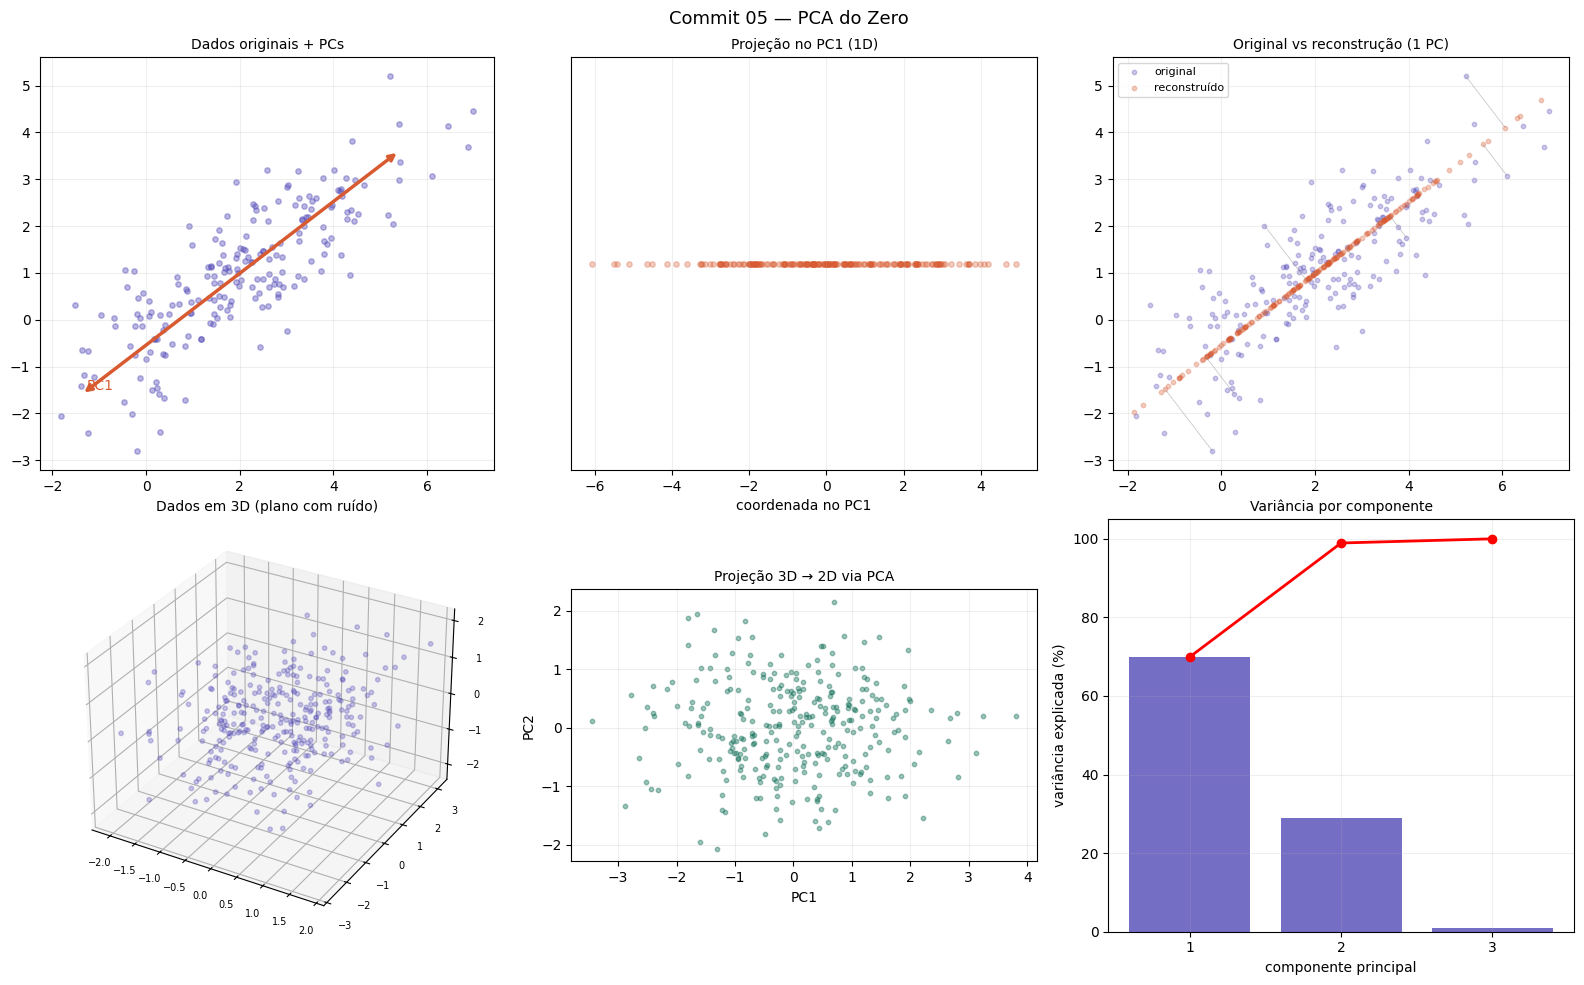

In [ ]:
# graficos

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Commit 05 — PCA do Zero", fontsize=13)

# Plot 1: dados 2D + componentes principais
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(X2d[:, 0], X2d[:, 1], alpha=0.4, s=15, color='#534AB7')
ax1.set_aspect('equal')
ax1.set_title("Dados originais + PCs", fontsize=10)
ax1.grid(True, alpha=0.2)
cores = ['#D85A30', '#0F6E56']
for i, (comp, val) in enumerate(zip(comp_cov.T, vals_cov)):
    escala = 2 * np.sqrt(val)
    ax1.annotate("", xy=mu_cov + escala*comp, xytext=mu_cov - escala*comp,
        arrowprops=dict(arrowstyle='<->', color=cores[i], lw=2.5))
    ax1.text(*(mu_cov + escala*comp + 0.1), f'PC{i+1}', color=cores[i], fontsize=10)

# Plot 2: projeção 1D
ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(Z_cov[:, 0], np.zeros(n), alpha=0.3, s=15, color='#D85A30')
ax2.set_title("Projeção no PC1 (1D)", fontsize=10)
ax2.set_xlabel("coordenada no PC1")
ax2.set_yticks([])
ax2.grid(True, alpha=0.2)

# Plot 3: original vs reconstruído
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(X2d[:, 0], X2d[:, 1], alpha=0.3, s=10, color='#534AB7', label='original')
ax3.scatter(X_rec_1[:, 0], X_rec_1[:, 1], alpha=0.3, s=10, color='#D85A30', label='reconstruído')
for i in range(0, n, 20):
    ax3.plot([X2d[i, 0], X_rec_1[i, 0]], [X2d[i, 1], X_rec_1[i, 1]],
             'gray', lw=0.5, alpha=0.5)
ax3.set_aspect('equal')
ax3.set_title("Original vs reconstrução (1 PC)", fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

# Plot 4: 3D scatter
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.scatter(X3d[:, 0], X3d[:, 1], X3d[:, 2], alpha=0.3, s=10, color='#534AB7')
ax4.set_title("Dados em 3D (plano com ruído)", fontsize=10)
ax4.tick_params(labelsize=7)

# Plot 5: dados 3D projetados em 2D
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(Z3d[:, 0], Z3d[:, 1], alpha=0.4, s=10, color='#0F6E56')
ax5.set_aspect('equal')
ax5.set_title("Projeção 3D → 2D via PCA", fontsize=10)
ax5.set_xlabel("PC1"); ax5.set_ylabel("PC2")
ax5.grid(True, alpha=0.2)

# Plot 6: variância explicada acumulada
ax6 = fig.add_subplot(2, 3, 6)
_, _, vals_all, _ = pca_covariancia(X3d, 3)
ve = vals_all / vals_all.sum() * 100
ax6.bar(range(1, 4), ve, color='#534AB7', alpha=0.8)
ax6.plot(range(1, 4), np.cumsum(ve), 'ro-', lw=2, ms=6)
ax6.set_xticks(range(1, 4))
ax6.set_xlabel("componente principal")
ax6.set_ylabel("variância explicada (%)")
ax6.set_title("Variância por componente", fontsize=10)
ax6.grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig('../assets/05_pca.png', dpi=150, bbox_inches='tight')
plt.show()
